In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

 Charger les données

In [3]:
features = pd.read_csv('data/processed/features_churn.csv')

FEATURE_COLS = [
    'Frequency', 'Monetary', 'Avg_OrderValue',
    'Nb_Produits', 'Avg_Quantity', 'Nb_Jours_Actif',
    'Total_Items', 'Cadence', 'Panier_Moyen'
]

X = features[FEATURE_COLS]
y = features['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Données chargées : {X.shape}")
print(f"   Train : {len(X_train):,} | Test : {len(X_test):,}")

Données chargées : (4338, 9)
   Train : 3,470 | Test : 868


Scores de base (avant optimisation)

In [6]:
# Modèles de base pour comparaison
baseline_models = {
    'Random Forest'      : RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost'            : xgb.XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'LightGBM'           : lgb.LGBMClassifier(random_state=42, verbose=-1)
}

print("SCORES BASELINE (avant optimisation)")

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    baseline_results[name] = auc
    print(f"  {name:<25} AUC = {auc:.4f}")

print()
print(f"Meilleur baseline : {max(baseline_results, key=baseline_results.get)}")

SCORES BASELINE (avant optimisation)
  Random Forest             AUC = 0.8057
  XGBoost                   AUC = 0.7858
  Logistic Regression       AUC = 0.8159
  LightGBM                  AUC = 0.8069

Meilleur baseline : Logistic Regression


**Recherche Randomisée sur les 4 modèles**

Forêt aléatoire optimisée

In [ ]:
print("Optimisation Random Forest...")

rf_params = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [5, 10, 15, 20, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'class_weight'      : [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
rf_auc  = roc_auc_score(y_test, rf_best.predict_proba(X_test)[:, 1])

print(f"\n Random Forest optimisé !")
print(f"   Meilleurs params : {rf_search.best_params_}")
print(f"   AUC baseline     : {baseline_results['Random Forest']:.4f}")
print(f"   AUC optimisé     : {rf_auc:.4f}")
print(f"   Gain             : +{(rf_auc - baseline_results['Random Forest']):.4f}")

Optimisation Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Random Forest optimisé !
   Meilleurs params : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 5, 'class_weight': 'balanced'}
   AUC baseline     : 0.8057
   AUC optimisé     : 0.8264
   Gain             : +0.0207


XGBoost optimisé

In [6]:
print("⏳ Optimisation XGBoost...")

xgb_params = {
    'n_estimators'  : [100, 200, 300, 500],
    'max_depth'     : [3, 4, 5, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'         : [0, 0.1, 0.2, 0.5],
    'scale_pos_weight': [1, 2, 3]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, verbosity=0,
                      eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)

xgb_best = xgb_search.best_estimator_
xgb_auc  = roc_auc_score(y_test, xgb_best.predict_proba(X_test)[:, 1])

print(f"\nXGBoost optimisé !")
print(f"   Meilleurs params : {xgb_search.best_params_}")
print(f"   AUC baseline     : {baseline_results['XGBoost']:.4f}")
print(f"   AUC optimisé     : {xgb_auc:.4f}")
print(f"   Gain             : +{(xgb_auc - baseline_results['XGBoost']):.4f}")

⏳ Optimisation XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ XGBoost optimisé !
   Meilleurs params : {'subsample': 0.6, 'scale_pos_weight': 2, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}
   AUC baseline     : 0.7858
   AUC optimisé     : 0.8275
   Gain             : +0.0418


Régression logistique optimisée

In [7]:
print("Optimisation Logistic Regression...")

# Standardisation nécessaire pour LR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_params = {
    'C'            : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'      : ['l1', 'l2', 'elasticnet'],
    'solver'       : ['saga'],
    'l1_ratio'     : [0.1, 0.3, 0.5, 0.7, 0.9],
    'class_weight' : [None, 'balanced'],
    'max_iter'     : [1000, 2000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=lr_params,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lr_search.fit(X_train_scaled, y_train)

lr_best = lr_search.best_estimator_
lr_auc  = roc_auc_score(y_test,
          lr_best.predict_proba(X_test_scaled)[:, 1])

print(f"\n Logistic Regression optimisée !")
print(f"   Meilleurs params : {lr_search.best_params_}")
print(f"   AUC baseline     : {baseline_results['Logistic Regression']:.4f}")
print(f"   AUC optimisé     : {lr_auc:.4f}")
print(f"   Gain             : +{(lr_auc - baseline_results['Logistic Regression']):.4f}")

⏳ Optimisation Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Logistic Regression optimisée !
   Meilleurs params : {'solver': 'saga', 'penalty': 'l2', 'max_iter': 2000, 'l1_ratio': 0.7, 'class_weight': None, 'C': 0.01}
   AUC baseline     : 0.8159
   AUC optimisé     : 0.8160
   Gain             : +0.0001


LightGBM optimisé

In [8]:
print("⏳ Optimisation LightGBM...")

lgb_params = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 5, 7, 10, -1],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'      : [15, 31, 63, 127],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 30],
    'class_weight'    : [None, 'balanced'],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0, 0.1, 0.5, 1.0]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_params,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lgb_search.fit(X_train, y_train)

lgb_best = lgb_search.best_estimator_
lgb_auc  = roc_auc_score(y_test,
           lgb_best.predict_proba(X_test)[:, 1])

print(f"\n LightGBM optimisé !")
print(f"   Meilleurs params : {lgb_search.best_params_}")
print(f"   AUC baseline     : {baseline_results['LightGBM']:.4f}")
print(f"   AUC optimisé     : {lgb_auc:.4f}")
print(f"   Gain             : +{(lgb_auc - baseline_results['LightGBM']):.4f}")

⏳ Optimisation LightGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ LightGBM optimisé !
   Meilleurs params : {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7, 'class_weight': None}
   AUC baseline     : 0.8069
   AUC optimisé     : 0.8264
   Gain             : +0.0195


 **Comparaison finale**

 Tableau comparatif complet

In [9]:
from sklearn.metrics import f1_score

# Compiler tous les résultats
optimized_results = {
    'Random Forest'      : (rf_best,  X_test),
    'XGBoost'            : (xgb_best, X_test),
    'Logistic Regression': (lr_best,  X_test_scaled),
    'LightGBM'           : (lgb_best, X_test)
}

print("COMPARAISON FINALE — BASELINE vs OPTIMISÉ")

print(f"{'Modèle':<25} {'AUC Base':>10} {'AUC Opt':>10} {'Gain':>8} {'F1':>8}")
print("-" * 70)

final_results = []
for name, (model, X_t) in optimized_results.items():
    proba  = model.predict_proba(X_t)[:, 1]
    pred   = model.predict(X_t)
    auc    = roc_auc_score(y_test, proba)
    f1     = f1_score(y_test, pred)
    gain   = auc - baseline_results[name]
    final_results.append({
        'Modèle': name, 'AUC_Base': baseline_results[name],
        'AUC_Opt': auc, 'Gain': gain, 'F1': f1
    })
    print(f"{name:<25} {baseline_results[name]:>10.4f} "
          f"{auc:>10.4f} {gain:>+8.4f} {f1:>8.4f}")

best_name = max(final_results, key=lambda x: x['AUC_Opt'])['Modèle']
best_auc  = max(final_results, key=lambda x: x['AUC_Opt'])['AUC_Opt']
print(f" MEILLEUR MODÈLE : {best_name} (AUC = {best_auc:.4f})")

🏆 COMPARAISON FINALE — BASELINE vs OPTIMISÉ
Modèle                      AUC Base    AUC Opt     Gain       F1
----------------------------------------------------------------------
Random Forest                 0.8057     0.8264  +0.0207   0.6818
XGBoost                       0.7858     0.8275  +0.0418   0.6834
Logistic Regression           0.8159     0.8160  +0.0001   0.6149
LightGBM                      0.8069     0.8264  +0.0195   0.5212
🥇 MEILLEUR MODÈLE : XGBoost (AUC = 0.8275)


Graphique comparatif

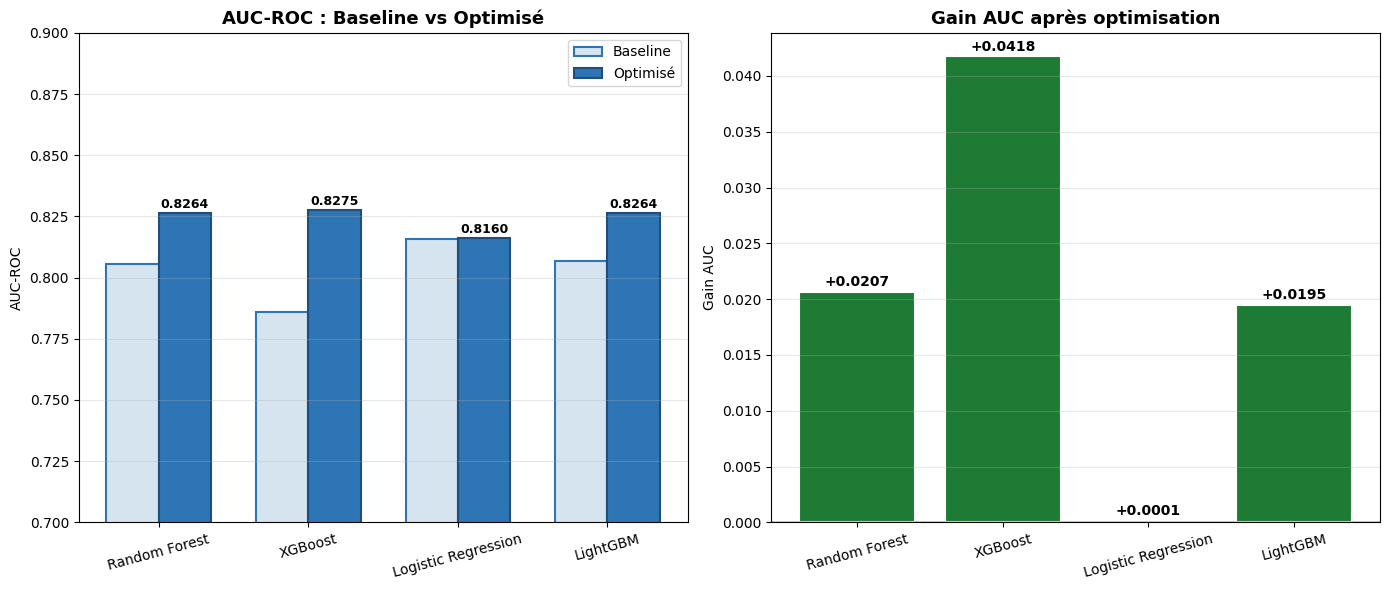

In [10]:
df_results = pd.DataFrame(final_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AUC Baseline vs Optimisé
x = np.arange(len(df_results))
width = 0.35

axes[0].bar(x - width/2, df_results['AUC_Base'],
            width, label='Baseline', color='#D6E4F0',
            edgecolor='#2E75B6', linewidth=1.5)
axes[0].bar(x + width/2, df_results['AUC_Opt'],
            width, label='Optimisé', color='#2E75B6',
            edgecolor='#1F4E79', linewidth=1.5)

axes[0].set_title('AUC-ROC : Baseline vs Optimisé',
                   fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results['Modèle'], rotation=15)
axes[0].set_ylabel('AUC-ROC')
axes[0].legend()
axes[0].set_ylim(0.7, 0.9)
axes[0].grid(True, alpha=0.3, axis='y')

for i, (base, opt) in enumerate(zip(df_results['AUC_Base'],
                                     df_results['AUC_Opt'])):
    axes[0].text(i + width/2, opt + 0.002,
                 f'{opt:.4f}', ha='center', fontsize=9, fontweight='bold')

# Gain par modèle
colors = ['#1E7B34' if g > 0 else '#C55A11'
          for g in df_results['Gain']]
axes[1].bar(df_results['Modèle'], df_results['Gain'],
            color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Gain AUC après optimisation',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gain AUC')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xticklabels(df_results['Modèle'], rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

for i, gain in enumerate(df_results['Gain']):
    axes[1].text(i, gain + 0.0005,
                 f'{gain:+.4f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('',
            dpi=150, bbox_inches='tight')
plt.show()

 Sauvegarder le meilleur modèle

In [12]:
# Identifier et sauvegarder le meilleur modèle
best_model_name = max(final_results,
                      key=lambda x: x['AUC_Opt'])['Modèle']

best_model_map = {
    'Random Forest'      : rf_best,
    'XGBoost'            : xgb_best,
    'Logistic Regression': lr_best,
    'LightGBM'           : lgb_best
}

best_model = best_model_map[best_model_name]

joblib.dump(best_model, 'models/best_model_optimized.pkl')

if best_model_name == 'Logistic Regression':
    joblib.dump(scaler, 'models/scaler_lr.pkl')

# Mettre à jour le score churn avec le meilleur modèle
X_best = X_test_scaled if best_model_name == 'Logistic Regression' \
         else X_test
X_all  = scaler.transform(X) if best_model_name == 'Logistic Regression' \
         else X

features['Churn_Score_Optimized'] = best_model.predict_proba(X_all)[:, 1]
features.to_csv('data/processed/features_churn1.csv', index=False)

print("OPTIMISATION TERMINÉE !")
print(f"Meilleur modèle    : {best_model_name}")
print(f"AUC-ROC optimisé   : {best_auc:.4f}")
print(f"AUC-ROC baseline   : {baseline_results[best_model_name]:.4f}")
print(f"Gain total         : +{best_auc - baseline_results[best_model_name]:.4f}")
print()
print("Fichiers sauvegardés :")
print("  → models/best_model_optimized.pkl")
print("  → data/processed/features_churn.csv (scores mis à jour)")

✅ OPTIMISATION TERMINÉE !
Meilleur modèle    : XGBoost
AUC-ROC optimisé   : 0.8275
AUC-ROC baseline   : 0.7858
Gain total         : +0.0418

Fichiers sauvegardés :
  → models/best_model_optimized.pkl
  → data/processed/features_churn.csv (scores mis à jour)
